In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

import corner

from SabinasStarryProcess1 import *

from jaxoplanet.starry.ylm import Ylm
from jaxoplanet.starry.surface import Surface


/Users/sabina/Desktop/GitHub/StarryStarryProcessJaxoplanet/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import scipy

from jaxoplanet.core.limb_dark import light_curve as _limb_dark_light_curve
from jaxoplanet.starry.core.basis import A1, A2_inv, U
from jaxoplanet.starry.core.polynomials import Pijk
from jaxoplanet.starry.core.rotation import left_project
from jaxoplanet.starry.core.solution import rT, solution_vector
from jaxoplanet.starry.surface import Surface
from jaxoplanet.starry.system_observable import system_observable

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.diagnostics import summary


def design_matrix(
    surface: Surface,
    r: float | None = None,
    x: float | None = None,
    y: float | None = None,
    z: float | None = None,
    theta: float | None = None,
    order: int = 20,
    higher_precision: bool = False,
):
    """Light curve of an occulted surface.

    Args:
        surface (Surface): Surface object
        r (float or None): radius of the occulting body, relative to the current map
           body
        x (float or None): x coordinate of the occulting body relative to the surface
           center. By default (None) 0.0
        y (float or None): y coordinate of the occulting body relative to the surface
           center. By default (None) 0.0
        z (float or None): z coordinate of the occulting body relative to the surface
           center. By default (None) 0.0
        theta (float):
            rotation angle of the map, in radians. By default 0.0
        order (int):
            order of the P integral numerical approximation. By default 20
        higher_precision (bool): whether to compute change of basis matrix as hight
            precision. By default False (only used to testing).

    Returns:
        ArrayLike: flux
    """
    if higher_precision:
        try:
            from jaxoplanet.starry.multiprecision import (
                basis as basis_mp,
                utils as utils_mp,
            )
        except ImportError as e:
            raise ImportError(
                "The `mpmath` Python package is required for higher_precision=True."
            ) from e

    total_deg = surface.deg

    rT_deg = rT(total_deg)

    x = 0.0 if x is None else x
    y = 0.0 if y is None else y
    z = 0.0 if z is None else z

    # no occulting body
    if r is None:
        b_rot = True
        theta_z = 0.0
        design_matrix_p = rT_deg

    # occulting body
    else:
        b = jnp.sqrt(jnp.square(x) + jnp.square(y))
        b_rot = jnp.logical_or(jnp.greater_equal(b, 1.0 + r), jnp.less_equal(z, 0.0))
        b_occ = jnp.logical_not(b_rot)

        # trick to avoid nan `x=jnp.where...` grad caused by nan sT
        r = jnp.where(b_rot, 1.0, r)
        b = jnp.where(b_rot, 1.0, b)

        if surface.ydeg == 0:
            if surface.udeg == 0:
                ld_u = jnp.array([])
            else:
                ld_u = jnp.concatenate(
                    [jnp.atleast_1d(jnp.asarray(u_)) for u_ in surface.u], axis=0
                )

            lc_func = partial(_limb_dark_light_curve, ld_u, order=order)
            lc = lc_func(b, r)
            return surface.amplitude * (1.0 + jnp.where(b_occ, lc, 0))

        else:
            theta_z = jnp.arctan2(x, y)
            sT = solution_vector(total_deg, order=order)(b, r)

        if total_deg > 0:
            if higher_precision:
                A2 = np.atleast_2d(utils_mp.to_numpy(basis_mp.A2(total_deg)))
            else:
                A2 = scipy.sparse.linalg.inv(A2_inv(total_deg))
                A2 = jax.experimental.sparse.BCOO.from_scipy_sparse(A2)
        else:
            A2 = jnp.array([[1]])

        design_matrix_p = jnp.where(b_occ, sT @ A2, rT_deg)

    # limb darkening
    if surface.udeg == 0:
        p_u = Pijk.from_dense(jnp.array([1]))
    else:
        u = jnp.array([1, *surface.u])
        p_u = Pijk.from_dense(u @ U(surface.udeg), degree=surface.udeg)

    # surface map * limb darkening map
    if higher_precision:
        A1_val = np.atleast_2d(utils_mp.to_numpy(basis_mp.A1(surface.ydeg)))
    else:
        A1_val = jax.experimental.sparse.BCOO.from_scipy_sparse(A1(surface.ydeg))

    norm = np.pi / (p_u.tosparse() @ rT(surface.udeg))

    N = (surface.ydeg + 1) ** 2
    def one_col(theta_i, ej):
        rotated_y = left_project(
            surface.ydeg, surface._inc, surface._obl, theta_i, theta_z, ej
        )
        p_y = Pijk.from_dense(A1_val @ rotated_y, degree=surface.ydeg)
        p_yu = p_y * p_u
        return surface.amplitude * (p_yu.tosparse() @ design_matrix_p) * norm

    over_basis = jax.vmap(one_col, in_axes=(None, 0))
    over_time = jax.vmap(over_basis, in_axes=(0, None))
    return jnp.real(over_time(theta, jnp.eye(N)))

In [3]:
lmax = 5
r = np.deg2rad(20.0)
c = 0.1
nspots = 10.0
period = 1.0

ncurves = 50
ntimes = 500
ferr = 1e-3

norm_order = 20
norm_zmax = 0.023

inc = np.pi / 2
obl = 0.0

t = jnp.linspace(0.0, 4.0, ntimes)
theta = 2.0 * jnp.pi * jnp.mod(t / period, 1.0)

# Starry Process defaults used by the original a,b transform.
LOG_ALPHA_MAX = 10.0
LOG_BETA_MAX = 10.0
LOG_BETA_MIN = np.log(0.5)

MU_TRUE_DEG = 60.0
SIGMA_TRUE_DEG = 5.0

seed = 123

In [4]:
def ab_to_alpha_beta(a, b):
    """Exact Starry Process mapping from dimensionless (a,b) to Beta(alpha,beta)."""
    alpha = jnp.exp(a * LOG_ALPHA_MAX)
    beta = jnp.exp(LOG_BETA_MIN + b * (LOG_BETA_MAX - LOG_BETA_MIN))
    return alpha, beta


def alpha_beta_to_ab(alpha, beta):
    """Exact inverse of ab_to_alpha_beta."""
    a = jnp.log(alpha) / LOG_ALPHA_MAX
    b = (jnp.log(beta) - LOG_BETA_MIN) / (LOG_BETA_MAX - LOG_BETA_MIN)
    return jnp.array([a, b])


def alpha_beta_to_latitude(alpha, beta):
    """Starry Process beta2gauss map, written in JAX.

    Returns (mu_deg, sigma_deg).
    """
    term = (4.0 * alpha**2 - 8.0 * alpha - 6.0 * beta + 4.0 * alpha * beta + beta**2 + 5.0)
    mu = 2.0 * jnp.arctan(jnp.sqrt(2.0 * alpha + beta - 2.0 - jnp.sqrt(term)))
    curvature = (1.0 - alpha + beta + (beta - 1.0) * jnp.cos(mu) + (alpha - 1.0) / jnp.cos(mu) ** 2)
    sigma = jnp.sin(mu) / jnp.sqrt(curvature)
    return jnp.array([mu, sigma]) * (180.0 / jnp.pi)


def ab_to_latitude(a, b):
    return alpha_beta_to_latitude(*ab_to_alpha_beta(a, b))

def gauss_to_ab(mu_deg, sigma_deg):
    mu = jnp.deg2rad(jnp.asarray(mu_deg))
    sigma2 = jnp.square(jnp.deg2rad(jnp.asarray(sigma_deg)))

    term = 1.0 / (16.0 * sigma2 * jnp.cos(0.5 * mu) ** 4)
    alpha = (2.0 + 4.0 * sigma2 + (3.0 + 8.0 * sigma2) * jnp.cos(mu) + 2.0 * jnp.cos(2.0 * mu) + jnp.cos(3.0 * mu)) * term
    beta = (jnp.cos(mu) + 2.0 * sigma2 * (3.0 + jnp.cos(2.0 * mu)) - jnp.cos(3.0 * mu)) * term
    return alpha_beta_to_ab(alpha, beta)


a_true, b_true = map(float, gauss_to_ab(MU_TRUE_DEG, SIGMA_TRUE_DEG))
alpha_true, beta_true = map(float, ab_to_alpha_beta(a_true, b_true))
mu_check, sigma_check = map(float, ab_to_latitude(a_true, b_true))

print("true a,b       =", a_true, b_true)
print("true alpha,beta=", alpha_true, beta_true)
print("recovered mu,sigma =", mu_check, sigma_check)


W0917 19:47:25.521363  279357 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


true a,b       = 0.3125631150885175 0.3557450107475467
true alpha,beta= 22.77426455563385 22.440931222300506
recovered mu,sigma = 60.00000000000071 4.9999999999999485


In [5]:
alpha, beta = ab_to_alpha_beta(a_true, b_true)
mean_ylm = compute_mean(alpha, beta, r, c, nspots, lmax=lmax)
cov_ylm  = compute_covariance(alpha, beta, r, c, nspots, lmax=lmax)

def moments_ab(a,b):
    alpha, beta = ab_to_alpha_beta(a, b)
    mean = compute_mean(alpha, beta, r, c, nspots, lmax=lmax)
    cov  = compute_covariance(alpha, beta, r, c, nspots, lmax=lmax)

    return mean, cov

In [6]:
dummy = Surface(y=Ylm.from_dense(jnp.zeros((lmax + 1) ** 2).at[0].set(1.0)),inc=inc,obl=obl,period=period,u=())
M = design_matrix(dummy, theta=theta)

def sample_ylm(mean_ylm, cov_ylm, key, nsamples, eps=1e-8):
    """Draw YLM realizations from N(mean_ylm, cov_ylm)."""
    ny = mean_ylm.shape[0]
    L = jnp.linalg.cholesky(cov_ylm + eps * jnp.eye(ny))
    z = jax.random.normal(key, (ny, nsamples))
    return (mean_ylm[:, None] + L @ z).T

def sample_flux(ylm_samples, M):
    """Project YLM realizations into unnormalized flux space."""
    return ylm_samples @ M.T

def normalize_flux_cov(mean_flux, cov_flux, norm_order=20):
    """Starry-process-style covariance of normalized flux perturbations.

    This is the same normalization algebra used in the original notebook.
    It returns (normalized_covariance, z), where z is the expansion parameter.
    """
    K = cov_flux.shape[0]
    mu = 1.0 + mean_flux[0]
    j = jnp.ones((K, 1), dtype=cov_flux.dtype)

    m = jnp.mean(cov_flux)
    q = (cov_flux @ j) / (K * m)
    p = j - q
    z = m / mu**2

    term = jnp.array(1.0, dtype=cov_flux.dtype)
    A = jnp.array(1.0, dtype=cov_flux.dtype)
    B = jnp.array(0.0, dtype=cov_flux.dtype)

    for jj in range(1, norm_order + 1):
        term = term * (2 * jj + 1) * z
        A = A + term
        B = B + 2 * jj * term

    normalized_cov = ((A / mu**2) * cov_flux + z * ((A + B) * (p @ p.T) - A * (q @ q.T)))
    normalized_cov = 0.5 * (normalized_cov + normalized_cov.T)
    return normalized_cov, z

mean_true, cov_true = moments_ab(a_true, b_true)

key = jax.random.PRNGKey(seed)
key_ylm, key_noise = jax.random.split(key)

ylm_samples = sample_ylm(mean_true, cov_true, key_ylm, ncurves)
flux_unnormalized = sample_flux(ylm_samples, M)

mean_flux_true = M @ mean_true
cov_flux_true = M @ cov_true @ M.T
normalized_cov_true, z_true = normalize_flux_cov(mean_flux_true,cov_flux_true,norm_order=norm_order)

L_norm = jnp.linalg.cholesky(normalized_cov_true + 1e-5 * jnp.eye(ntimes))
z_flux = jax.random.normal(key_noise, (ntimes, ncurves))
flux = (L_norm @ z_flux).T

measurement_noise = ferr * jax.random.normal(jax.random.fold_in(key_noise, 1),flux.shape)
f = flux + measurement_noise

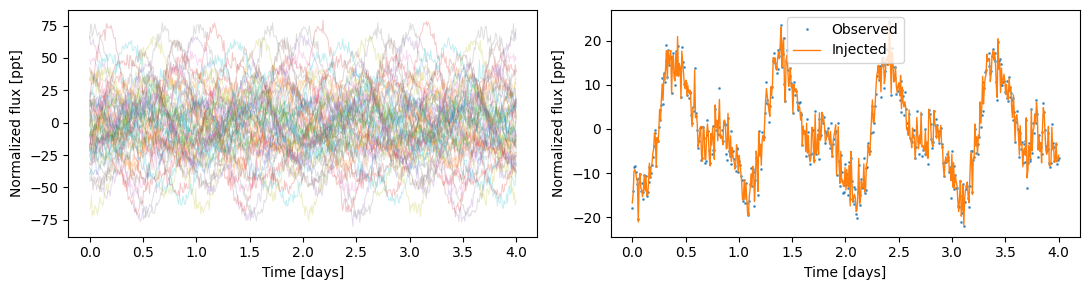

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(t, 1e3 * np.asarray(flux).T, alpha=0.25, lw=0.7)
axes[0].set(xlabel='Time [days]',ylabel='Normalized flux [ppt]')
axes[1].plot(t, 1e3 * np.asarray(f[0]), '.', ms=2, alpha=0.7, label='Observed')
axes[1].plot(t, 1e3 * np.asarray(flux[0]), lw=1, label='Injected')
axes[1].set(xlabel='Time [days]', ylabel='Normalized flux [ppt]')
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
@jax.jit
def log_likelihood_ab(a, b):
    mean_ylm, cov_ylm = moments_ab(a, b)
    mean_flux = M @ mean_ylm
    cov_flux = M @ cov_ylm @ M.T

    normalized_cov, z = normalize_flux_cov(mean_flux,cov_flux,norm_order=norm_order)

    valid = jnp.isfinite(z) & (z < norm_zmax) & (z > 0.0)

    K = normalized_cov + ferr**2 * jnp.eye(ntimes)
    L = jnp.linalg.cholesky(K + 1e-8 * jnp.eye(ntimes))

    # The normalized data are zero-mean by construction.
    resid = f
    alpha = jax.scipy.linalg.solve_triangular(L,resid.T,lower=True)

    quad = jnp.sum(alpha**2)
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))
    ndata = f.size

    ll = -0.5 * (quad + ncurves * logdet + ndata * jnp.log(2.0 * jnp.pi))

    return jnp.where(valid & jnp.isfinite(ll), ll, -jnp.inf)

In [9]:
ll_true = float(log_likelihood_ab(a_true, b_true))
grad_true = jax.grad(log_likelihood_ab, argnums=(0, 1))(a_true, b_true)
print('normalized log likelihood at truth:', ll_true)
print('gradient at truth:', float(grad_true[0]), float(grad_true[1]))

normalized log likelihood at truth: 12653.306197389622
gradient at truth: 273.436508412893 -333.5894587427156


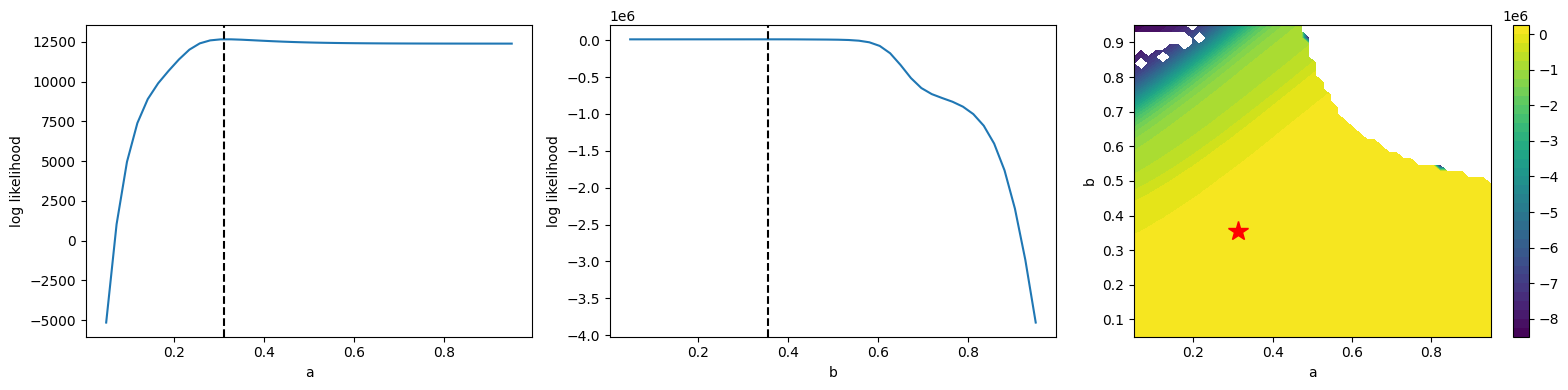

peak of a-slice at a = 0.32692307692307687  (truth 0.3125631150885175 )
peak of b-slice at b = 0.35  (truth 0.3557450107475467 )


In [26]:
grid = np.linspace(0.05, 0.95, 40)

ll_a = np.array([log_likelihood_ab(x, b_true) for x in grid])

ll_b = np.array([log_likelihood_ab(a_true, x) for x in grid])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(grid, ll_a)
ax[0].axvline(a_true, color="k", ls="--")
ax[0].set(xlabel="a",ylabel="log likelihood")

ax[1].plot(grid, ll_b)
ax[1].axvline(b_true, color="k", ls="--")
ax[1].set(xlabel="b",ylabel="log likelihood")

g = np.linspace(0.05, 0.95, 50)
Z = np.array([[log_likelihood_ab(a, b) for a in g] for b in g])

im = ax[2].contourf(g,g,Z,levels=40)
ax[2].plot(a_true,b_true,"r*",ms=15)
ax[2].set(xlabel="a",ylabel="b")

plt.colorbar(im, ax=ax[2])
plt.tight_layout()
plt.show()

print("peak of a-slice at a =",grid[np.nanargmax(ll_a)]," (truth",a_true,")")
print("peak of b-slice at b =",grid[np.nanargmax(ll_b)]," (truth",b_true,")")

In [11]:
def model():
    a = numpyro.sample('a', dist.Uniform(1e-4, 1.0))
    b = numpyro.sample('b', dist.Uniform(1e-4, 1.0))
    ll = log_likelihood_ab(a, b)
    numpyro.factor('loglik_factor', ll)
    numpyro.deterministic('log_likelihood', ll)

kernel = NUTS(model, target_accept_prob=0.8, dense_mass=False)
mcmc = MCMC(kernel,num_warmup=200,num_samples=600,num_chains=1,progress_bar=True)

mcmc.run(jax.random.PRNGKey(seed + 1))
mcmc.print_summary()
samples = mcmc.get_samples()

sample: 100%|██████████| 800/800 [15:00<00:00,  1.13s/it, 15 steps of size 3.33e-02. acc. prob=0.92] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a      0.33      0.10      0.31      0.19      0.49     79.99      1.00
         b      0.37      0.09      0.35      0.25      0.51     79.20      1.00

Number of divergences: 43


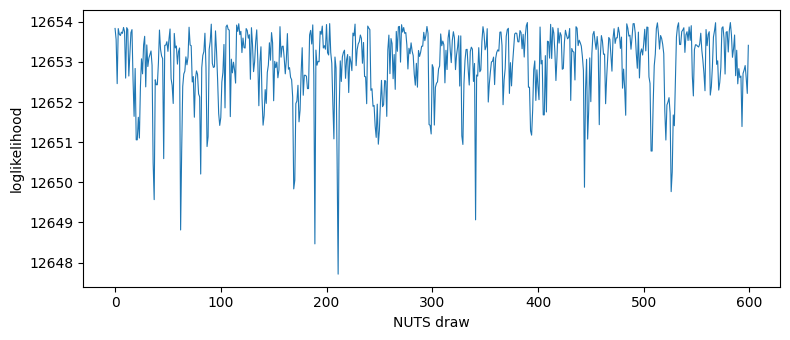

In [12]:
ll_trace = np.asarray(mcmc.get_samples()['log_likelihood'])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ll_trace, lw=0.8)
ax.set(xlabel='NUTS draw', ylabel='loglikelihood')
plt.tight_layout()
plt.show()

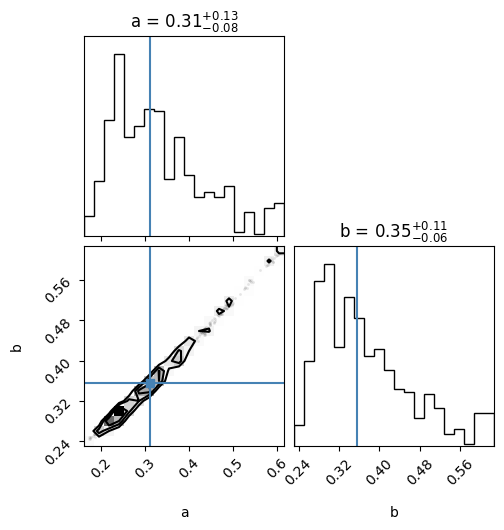

In [13]:
import corner

arr_ab = np.column_stack([np.asarray(samples['a']), np.asarray(samples['b'])])
fig = corner.corner(
    arr_ab,
    labels=['a', 'b'],
    truths=[a_true, b_true],
    show_titles=True,
)
plt.show()

In [14]:
mu_sigma_post = jax.vmap(ab_to_latitude)(samples['a'], samples['b'])
mu_post = np.asarray(mu_sigma_post[:, 0])
sigma_post = np.asarray(mu_sigma_post[:, 1])

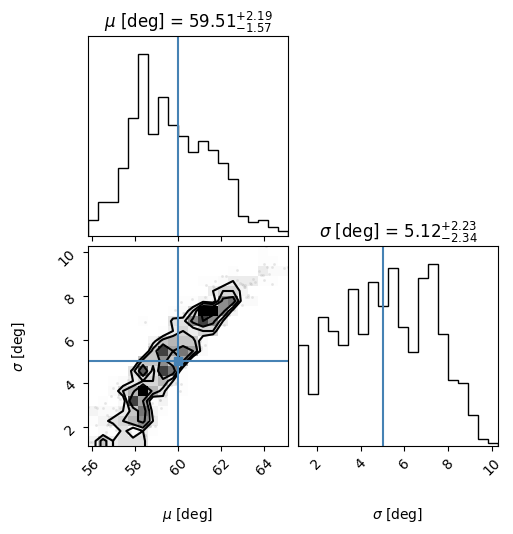

In [15]:
fig = corner.corner(
    np.column_stack([mu_post, sigma_post]),
    labels=[r'$\mu$ [deg]', r'$\sigma$ [deg]'],
    truths=[MU_TRUE_DEG, SIGMA_TRUE_DEG],
    show_titles=True,
)
plt.show()

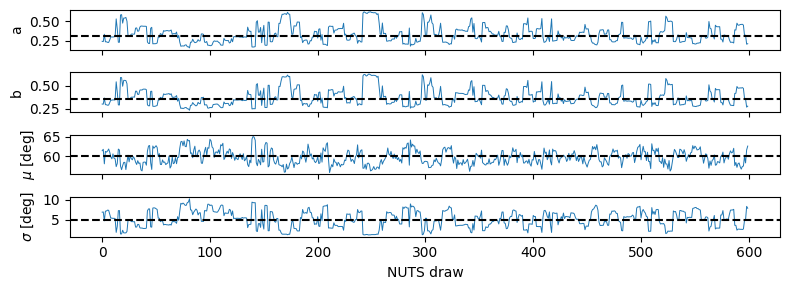

In [17]:
a_trace = np.asarray(samples["a"])
b_trace = np.asarray(samples["b"])

mu_sigma_trace = np.asarray(jax.vmap(ab_to_latitude)(samples["a"],samples["b"]))

mu_trace = mu_sigma_trace[:, 0]
sigma_trace = mu_sigma_trace[:, 1]

fig, axes = plt.subplots(4,1,figsize=(8, 3),sharex=True,)

axes[0].plot(a_trace, lw=0.7)
axes[0].axhline(a_true, color="k", ls="--")
axes[0].set_ylabel("a")

axes[1].plot(b_trace, lw=0.7)
axes[1].axhline(b_true, color="k", ls="--")
axes[1].set_ylabel("b")

axes[2].plot(mu_trace, lw=0.7)
axes[2].axhline(MU_TRUE_DEG, color="k", ls="--")
axes[2].set_ylabel(r"$\mu$ [deg]")

axes[3].plot(sigma_trace, lw=0.7)
axes[3].axhline(SIGMA_TRUE_DEG, color="k", ls="--")
axes[3].set_ylabel(r"$\sigma$ [deg]")
axes[3].set_xlabel("NUTS draw")

plt.tight_layout()
plt.show()

In [18]:
def sample_normalized_flux(alpha, beta, key, r=r, c=c, nspots=nspots, lmax=lmax):
    mean_ylm = compute_mean(alpha, beta, r, c, nspots, lmax=lmax)
    cov_ylm = compute_covariance(alpha, beta, r, c, nspots, lmax=lmax)

    ylm_sample = sample_ylm(mean_ylm, cov_ylm, key, nsamples=1)[0]
    flux_perturbation = M @ ylm_sample

    mean_flux_perturbation = jnp.mean(flux_perturbation)
    normalized_flux = (flux_perturbation - mean_flux_perturbation) / (1.0 + mean_flux_perturbation)

    return normalized_flux

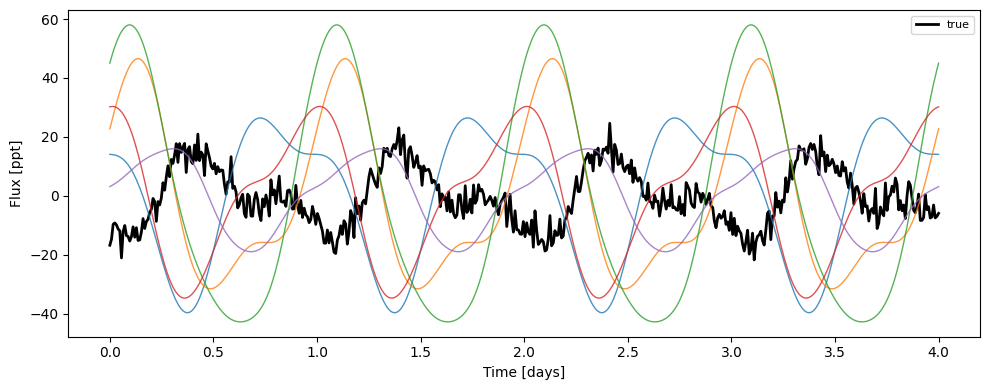

In [19]:
rng = np.random.default_rng(123)

a_post = np.asarray(samples["a"])
b_post = np.asarray(samples["b"])

n_show = 5
idx = rng.choice(len(a_post), size=n_show, replace=False)
keys = jax.random.split(jax.random.PRNGKey(12345), n_show)

plt.figure(figsize=(10, 4))

plt.plot(t, 1e3 * np.asarray(flux[0]), color="k", lw=2, label="true")

for j, (i, key) in enumerate(zip(idx, keys)):
    alpha_i, beta_i = ab_to_alpha_beta(a_post[i], b_post[i])
    model_flux = sample_normalized_flux(alpha_i, beta_i, key)
    plt.plot(t, 1e3 * np.asarray(model_flux), lw=1, alpha=0.8)

plt.xlabel("Time [days]")
plt.ylabel("Flux [ppt]")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
def conditional_ylm(mean_ylm,cov_ylm,f,M,ferr):
    f = jnp.atleast_2d(f)

    Cn = ferr**2*jnp.eye(M.shape[0])
    Cf = M@cov_ylm@M.T + Cn
    K = cov_ylm@M.T

    resid = f - M@mean_ylm
    solved_resid = jnp.linalg.solve(Cf,resid.T)

    mean_post = mean_ylm + (K@solved_resid).T
    cov_post = cov_ylm - K@jnp.linalg.solve(Cf,K.T)

    return mean_post,cov_post


def sample_conditional_ylm(mean_ylm,cov_ylm,f,M,ferr,key,nsamples=1,eps=1e-8):
    mean_post,cov_post = conditional_ylm(mean_ylm,cov_ylm,f,M,ferr)

    N = mean_post.shape[-1]
    L = jnp.linalg.cholesky(cov_post + eps*jnp.eye(N))
    z = jax.random.normal(key,(mean_post.shape[0],nsamples,N))

    return mean_post[:,None,:] + jnp.einsum("ij,csj->csi",L,z)


def sample_conditional_flux(mean_ylm,cov_ylm,f,M,ferr,key,nsamples=1,eps=1e-8):
    ylm_samples = sample_conditional_ylm(
        mean_ylm,cov_ylm,f,M,ferr,key,nsamples,eps
    )

    return jnp.einsum("csn,tn->cst",ylm_samples,M)

In [22]:
key = jax.random.PRNGKey(123)

flux_cond = sample_conditional_flux(mean_true,cov_true,f,M,ferr,key,nsamples=500)

i = 36

f_obs = f[i]
flux_cond_i = flux_cond[i]

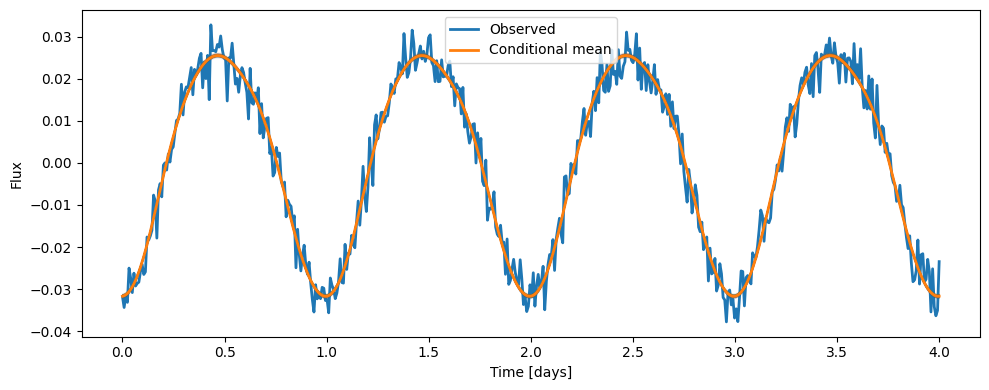

In [23]:
fig,ax = plt.subplots(figsize=(10,4))

ax.plot(t,f_obs,lw=2,label="Observed")
ax.plot(t,flux_cond_i.T,alpha=0.03,lw=0.7)
ax.plot(t,jnp.mean(flux_cond_i,axis=0),lw=2,label="Conditional mean")

ax.set_xlabel("Time [days]")
ax.set_ylabel("Flux")
ax.legend()

plt.tight_layout()
plt.show()

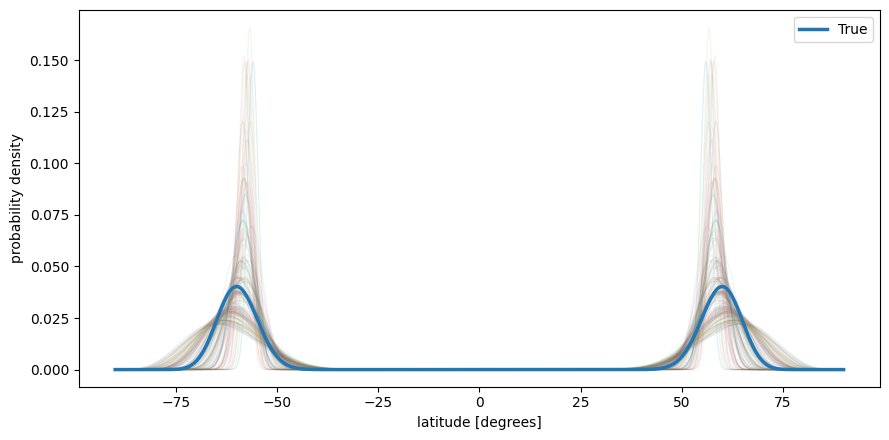

In [24]:
from scipy.stats import beta as beta_dist

phi = np.linspace(-90, 90, 1000)
phi_rad = np.deg2rad(phi)
x = np.cos(phi_rad)

alpha_post, beta_post = jax.vmap(ab_to_alpha_beta)(
    samples["a"], samples["b"]
)
alpha_post = np.asarray(alpha_post)
beta_post = np.asarray(beta_post)

alpha_true, beta_true = map(float, ab_to_alpha_beta(a_true, b_true))

jac = 0.5 * np.abs(np.sin(phi_rad)) * np.pi / 180.0
pdf_true = jac * beta_dist.pdf(x, alpha_true, beta_true)

fig, ax = plt.subplots(figsize=(9, 4.5))

nsamples_plot = min(200, len(alpha_post))
for alpha, beta in zip(alpha_post[:nsamples_plot], beta_post[:nsamples_plot]):
    pdf = jac * beta_dist.pdf(x, alpha, beta)
    ax.plot(phi, pdf, alpha=0.08, lw=0.8)

ax.plot(phi, pdf_true, lw=2.5, label="True")

ax.set_xlabel("latitude [degrees]")
ax.set_ylabel("probability density")
ax.legend()

plt.tight_layout()
plt.show()